[Home](../../README.md)

### Model Evaluation

This is a demonstration of evaluating a model.

#### Step 1

Load the required dependencies.


In [26]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('../../style_Matplotlib_charts.mplstyle')
from sklearn.linear_model import LinearRegression
import pickle

####  Step 2

Load the model for testing

In [27]:
filename = 'my_saved_model_v1.sav'
model_A = pickle.load(open(filename, 'rb'))


(Optional) Load a second model if you want to do comparative testing

In [28]:
filename = 'my_saved_model_v1.sav'
model_B = pickle.load(open(filename, 'rb'))

####  Step 3
Open and parse the test data CSV file and store the data as variable array data objects.

In [30]:
x_col = 'BMI'
testing_data = pd.read_csv('2.4.1.testing_data.csv')
x_test = np.array(testing_data[x_col]).reshape(-1,1)
y_test = np.array(testing_data['Target'])

#### Step 5

Plot the test data features, targets and linear regression model to visually evaluate the model.

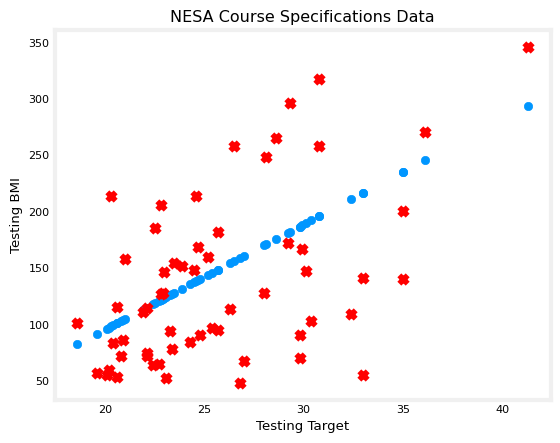

In [31]:
y_pred = model_A.predict(x_test)
plt.scatter(x_test, y_pred)
plt.scatter(x_test, y_test, marker='x', c='r')
plt.title("NESA Course Specifications Data")
plt.ylabel(f'Testing {x_col}')
plt.xlabel(f'Testing Target')
plt.show()

#### Step 6

Use the 'score' method of the `LinearRegression` class to return a score based evaluation of the models accuracy or performance.

In [32]:
test_score = model_A.score(x_test, y_test)
print(f'Training data score: {test_score}')

Training data score: 0.22413311929814617


#### Step 7

Manually calculate and evaluate the 'loss' and 'cost' of the model using the test data.

In [33]:
table = pd.DataFrame({
    testing_data.columns[0]: x_test.flatten(),  # Flatten x for easy display
    testing_data.columns[1]: y_test,
    'Predicted result':model_A.predict(x_test),
    'Loss' : abs(model_A.predict(x_test).round(2) - y_test)**2
})
print(table)
cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()

print(f"The cost or average loss of this model is {cost}")

     DoB    DoT  Predicted result        Loss
0   22.5  185.0        118.468601   4426.2409
1   25.7   95.0        148.319550   2843.0224
2   21.0  158.0        104.475969   2864.3904
3   22.9  128.0        122.199970     33.6400
4   23.3   94.0        125.931338   1019.5249
5   20.4   83.0         98.878916    252.1744
6   32.4  109.0        210.819974  10367.3124
7   24.7  168.0        138.991128    841.5801
8   22.4   64.0        117.535759   2866.5316
9   24.5  148.0        137.125444    118.1569
10  26.3  113.0        153.916603   1674.4464
11  23.1   52.0        124.065654   5194.0849
12  23.0  146.0        123.132812    523.0369
13  24.3   84.0        135.259760   2627.5876
14  28.1  248.0        170.707761   5973.7441
15  20.3  214.0         97.946074  13467.6025
16  33.0  141.0        216.417027   5688.1764
17  30.8  258.0        195.894500   3857.6521
18  29.8   70.0        186.566078  13588.5649
19  25.7  182.0        148.319550   1134.3424
20  20.6   53.0        100.744600 

You may want to do some manual predictions to understand your model.

In [34]:
print(model_A.predict([[0.1]]))
print(model_A.predict([[1]]))

[-90.48804019]
[-82.09246085]


#### Step 8

Evaluate the X axis intercept and gradient or coefficient of your model by using the getter methods to return the intercept and coefficient from my_model() object.

In [35]:
print(f'X Axis intercept: {model_A.intercept_}')
print(f'Coefficient: {model_A.coef_}')

X Axis intercept: -91.4208823406471
Coefficient: [9.32842149]


#### Step 9. Multiple Variable Linear Regression

You should be able to understand the code snippets with less guidelines.

In [36]:
filename = 'my_saved_model_v2.sav'
model_C = pickle.load(open(filename, 'rb'))

In [22]:
mx_col = ['BMI','BP','FDR']
testing_data = pd.read_csv('2.4.1.testing_data.csv')
mx_test = np.array(testing_data[mx_col])
my_test = np.array(testing_data['Target'])

In [37]:
my_pred = model_C.predict(mx_test)

# plot predictions and targets vs original features    
fig,ax=plt.subplots(1,len(mx_col),figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(mx_test[:,i],my_test, label = 'target')
    ax[i].set_xlabel(mx_col[i])
    ax[i].scatter(mx_test[:,i],my_pred,color="orange", label = 'predict')
    ax[i].set_ylabel("Target"); ax[i].legend();
fig.suptitle("Diabetes Disease Progress")
plt.show()

ValueError: X has 3 features, but LinearRegression is expecting 6 features as input.

In [24]:
test_score = model_C.score(mx_test, my_test)
print(f'Training data score: {test_score}')

ValueError: X has 3 features, but LinearRegression is expecting 6 features as input.

In [25]:
print(model_C.predict([[0.1,0.1,0.1]]))
print(model_C.predict([[1,0.5,1]]))

ValueError: X has 3 features, but LinearRegression is expecting 6 features as input.

In [ ]:
data = {col: mx_test[:, i] for i, col in enumerate(mx_col)}
data['Target'] = my_test
data['Predicted result'] = model_C.predict(mx_test)
data['Loss'] = abs(model_C.predict(mx_test).round(2) - my_test)**2
table = pd.DataFrame(data)

cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()
print(f"The cost or average loss of this model is {cost}")

print(table)

In [ ]:
print(f'X Axis intercept: {model_C.intercept_}')
print(f'Coefficient: {model_C.coef_}')

#### Step 10. Polynomial Linear Regression

You should be able to understand the code snippets with less guidelines.

In [ ]:
model_filename = 'my_saved_model_v3.sav'
poly_filename = 'my_saved_poly_v3.pkl'

model_D = pickle.load(open(model_filename, 'rb'))
poly = pickle.load(open(poly_filename, 'rb'))

In [ ]:
mx_col = ['BMI']
testing_data = pd.read_csv('2.4.1.testing_data.csv')
mx_test = np.array(testing_data[mx_col])
my_test = np.array(testing_data['Target'])

In [ ]:
poly_features = poly.fit_transform(mx_test)

In [ ]:
y_pred = model_D.predict(poly_features)

plt.scatter(x_test, y_pred)
plt.scatter(x_test, y_test, marker='x', c='r')
plt.title("NESA Course Specifications Data")
plt.ylabel(f'Testing {x_col}')
plt.xlabel(f'Testing Target')
plt.show()

In [ ]:
test_score = model_D.score(poly_features, my_test)
print(f'Training data score: {test_score}')

In [ ]:
new_poly_feature = poly.fit_transform([[0.1]])
print(model_D.predict(new_poly_feature))

In [ ]:
data = {col: mx_test[:, i] for i, col in enumerate(mx_col)}
data['Target'] = my_test
data['Predicted result'] = model_D.predict(poly_features)
data['Loss'] = abs(model_D.predict(poly_features).round(2) - my_test)**2
table = pd.DataFrame(data)

cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()
print(f"The cost or average loss of this model is {cost}")

print(table)

#### Step 11

When your model is ready for operations, move it to the [3.Operations\3.1.Deploy_Model](\3.Operations\3.1.Deploy_Model) folder.